In [4]:
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import matplotlib.dates as mdates

In [6]:
load_dotenv(encoding='utf-8')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

with engine.connect() as conn:
    print("Соединение успешно")

Соединение успешно


In [4]:
with engine.connect() as conn:
    df_mounthly = pd.read_sql(text("""
        SELECT
            DATE_TRUNC('month', "InvoiceDate") as mounth,
            COUNT(DISTINCT "Invoice") as orders,
            COUNT(DISTINCT "Customer ID") as customers,
            ROUND(SUM("Revenue")::numeric, 2) as revenue
        FROM transactions
        GROUP BY DATE_TRUNC('month', "InvoiceDate")
        ORDER BY mounth
    """), conn)

    print(df_mounthly)

       mounth  orders  customers     revenue
0  2009-12-01    1502        952   678379.57
1  2010-01-01     995        718   537491.50
2  2010-02-01    1093        771   498137.57
3  2010-03-01    1509       1051   666373.67
4  2010-04-01    1316        939   585499.93
5  2010-05-01    1365        965   592934.13
6  2010-06-01    1482       1035   629990.45
7  2010-07-01    1364        925   582147.96
8  2010-08-01    1276        910   595111.17
9  2010-09-01    1659       1136   805944.81
10 2010-10-01    2108       1492  1012421.50
11 2010-11-01    2571       1606  1157278.39
12 2010-12-01    1395        884   565749.56
13 2011-01-01     983        739   562882.91
14 2011-02-01     992        757   442493.59
15 2011-03-01    1312        973   583843.85
16 2011-04-01    1139        853   454840.88
17 2011-05-01    1544       1054   659678.49
18 2011-06-01    1390        990   653764.92
19 2011-07-01    1321        946   592103.79
20 2011-08-01    1268        933   635864.38
21 2011-09

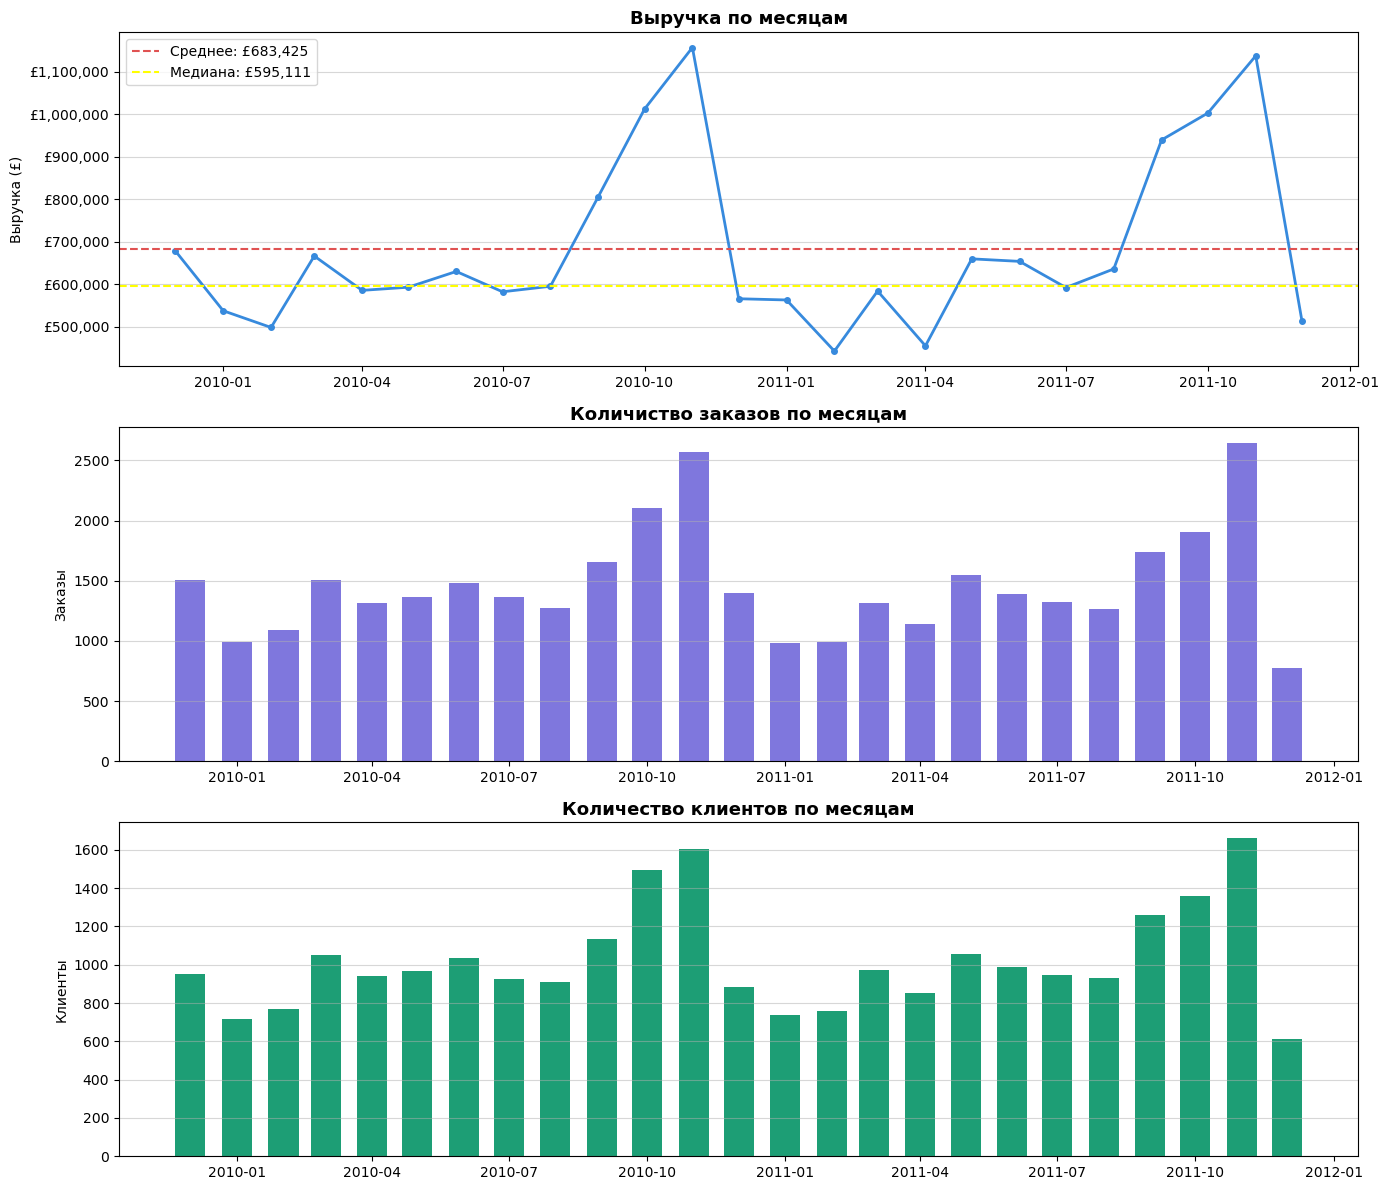

✅ График сохранён в monthly_revenue.png


In [5]:
fix, axes = plt.subplots(3, 1, figsize=(14, 12))

#--- График 1: Выручка ---
avg_revenue= df_mounthly['revenue'].mean()
med_revenue= df_mounthly['revenue'].median()
axes[0].plot(df_mounthly['mounth'], df_mounthly['revenue'],
            color='#378ADD', linewidth=2, marker='o', markersize=4)
axes[0].axhline(y=avg_revenue,  color='#E05252', linewidth=1.5,
                    linestyle='--', label=f'Среднее: £{avg_revenue:,.0f}')
axes[0].axhline(y=med_revenue,  color='#FFFF00', linewidth=1.5,
                    linestyle='--', label=f'Медиана: £{med_revenue:,.0f}')
axes[0].set_title('Выручка по месяцам', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Выручка (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].grid(axis='y', alpha=0.5)
axes[0].legend()
# --- График 2: Заказы ---
axes[1].bar(df_mounthly['mounth'], df_mounthly['orders'],
               color='#7F77DD', width=20)
axes[1].set_title('Количиство заказов по месяцам', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Заказы')
axes[1].grid(axis='y', alpha=0.5)
# --- График 3: Клиенты ---
axes[2].bar(df_mounthly['mounth'], df_mounthly['customers'],
               color='#1D9E75', width=20)
axes[2].set_title("Количество клиентов по месяцам", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Клиенты")
axes[2].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ График сохранён в monthly_revenue.png')

In [6]:
# -- топ-20 товаров по выручке
with engine.connect() as conn:
    df_products = pd.read_sql(text("""
        SELECT
            "StockCode",
            "Description",
            COUNT(DISTINCT "Invoice") as orders,
            SUM("Quantity") as total_quantity,
            ROUND(SUM("Revenue")::numeric, 2) as total_revenue,
            RANK() OVER(ORDER BY SUM("Revenue") DESC) as rank_revenue
        FROM transactions
        GROUP BY "StockCode", "Description"
        LIMIT 20
    """), conn)

print(df_products)

   StockCode                          Description  orders  total_quantity  \
0      22423             REGENCY CAKESTAND 3 TIER    3317         24124.0   
1     85123A   WHITE HANGING HEART T-LIGHT HOLDER    4888         91757.0   
2      23843          PAPER CRAFT , LITTLE BIRDIE       1         80995.0   
3     85099B              JUMBO BAG RED RETROSPOT    2612         74224.0   
4      84879        ASSORTED COLOUR BIRD ORNAMENT    2652         78234.0   
5      47566                        PARTY BUNTING    2077         23460.0   
6      23166       MEDIUM CERAMIC TOP STORAGE JAR     195         77916.0   
7      22086      PAPER CHAIN KIT 50'S CHRISTMAS     1691         28380.0   
8      79321                        CHILLI LIGHTS     922         14843.0   
9     85099F                 JUMBO BAG STRAWBERRY    1514         35842.0   
10     21137             BLACK RECORD COVER FRAME     539         18417.0   
11     84347  ROTATING SILVER ANGELS T-LIGHT HLDR     525         28606.0   

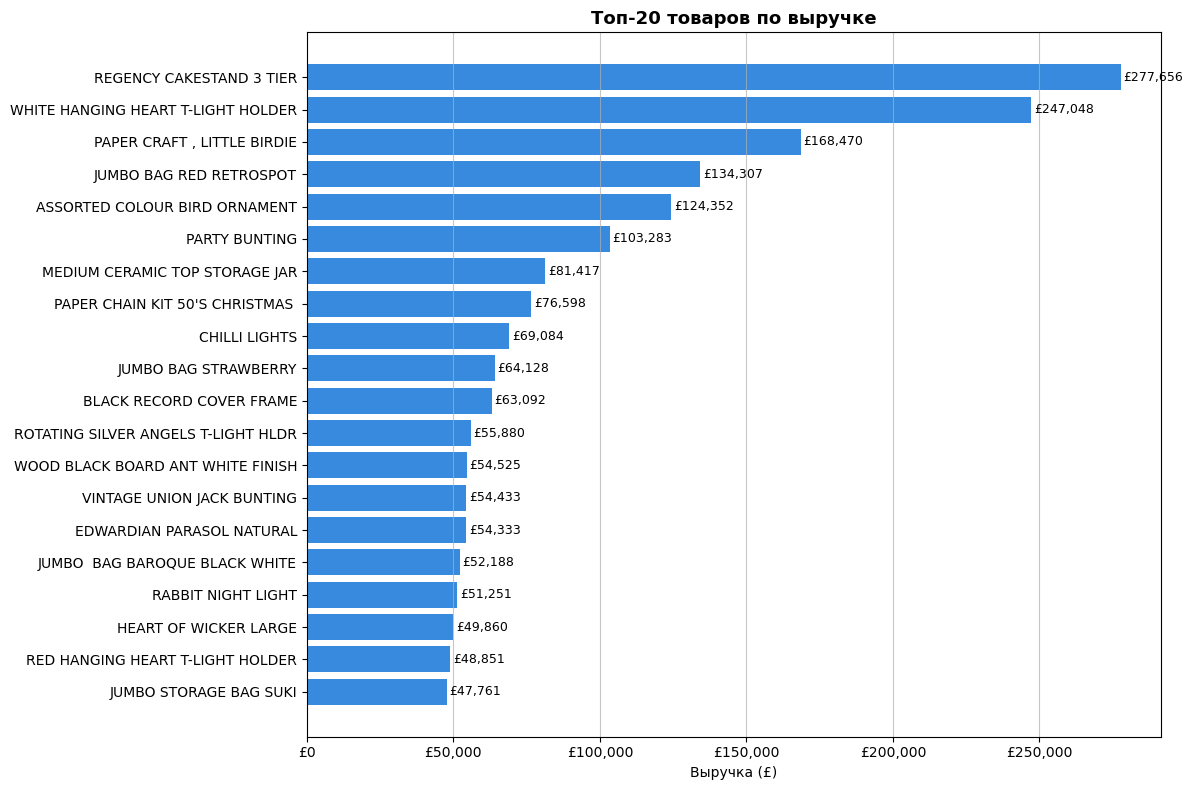

In [21]:
fig, ax = plt.subplots(figsize=(12,8))
bars = ax.barh(
    df_products["Description"],
    df_products["total_revenue"],
    color='#378ADD'
)
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1000,
        bar.get_y() + bar.get_height() / 2,
        f'£{width:,.0f}',
        va='center', fontsize=9
    )
ax.set_title('Топ-20 товаров по выручке', fontsize=13, fontweight='bold')
ax.set_xlabel('Выручка (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'£{x:,.0f}'))
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.7)

plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()

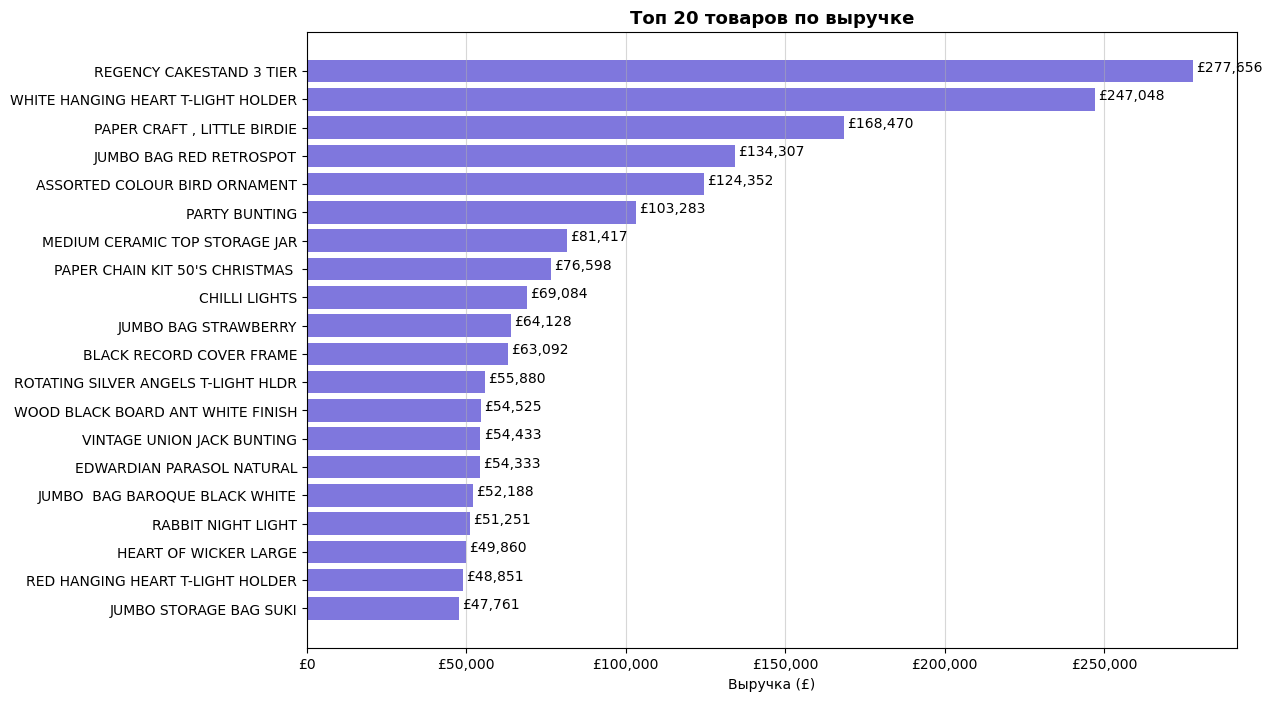

In [22]:
plt.figure(figsize=(12,8))
plt.barh(
    df_products['Description'],
    df_products['total_revenue'],
    color='#7F77DD'
)
for i, value in enumerate(df_products['total_revenue']):
    plt.text(
        value + 1000,
        i,
        f'£{value:,.0f}'
    )
plt.title('Топ 20 товаров по выручке', fontsize=13, fontweight='bold')
plt.xlabel('Выручка (£)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.5)

In [35]:
with engine.connect() as conn:
    df_customers = pd.read_sql(text("""
    select
	"Customer ID",
	COUNT(distinct "Invoice" ) as orders,
	round(SUM("Revenue")::numeric, 2) as total_revenue,
	round(sum(sum("Revenue")) over()::numeric, 2) as total,
	round(avg("Revenue")::numeric, 2) as avg_order_value,
	min("InvoiceDate") as first_purchase,
	max("InvoiceDate") as last_purchase,
	rank() over (order by sum("Revenue") desc) as revenue_rank,
	round((SUM("Revenue") * 100 / sum(sum("Revenue")) over())::numeric, 2) as revenue_share_pct
from transactions
group by "Customer ID"
limit 20;
    """),conn)
    print(df_customers)

    Customer ID  orders  total_revenue        total  avg_order_value  \
0         18102     145      580987.04  17085624.29           558.64   
1         14646     145      526751.52  17085624.29           137.93   
2         14156     151      305259.17  17085624.29            75.69   
3         14911     378      280026.15  17085624.29            25.33   
4         17450      51      244784.25  17085624.29           582.82   
5         13694     143      195640.69  17085624.29           128.80   
6         17511      60      172132.87  17085624.29            92.15   
7         16446       2      168472.50  17085624.29         56157.50   
8         16684      55      147142.77  17085624.29           204.93   
9         12415      24      144033.37  17085624.29           156.22   
10        15061     127      126387.57  17085624.29           140.90   
11        15311     207      114671.42  17085624.29            26.65   
12        13089     203      113416.91  17085624.29            3

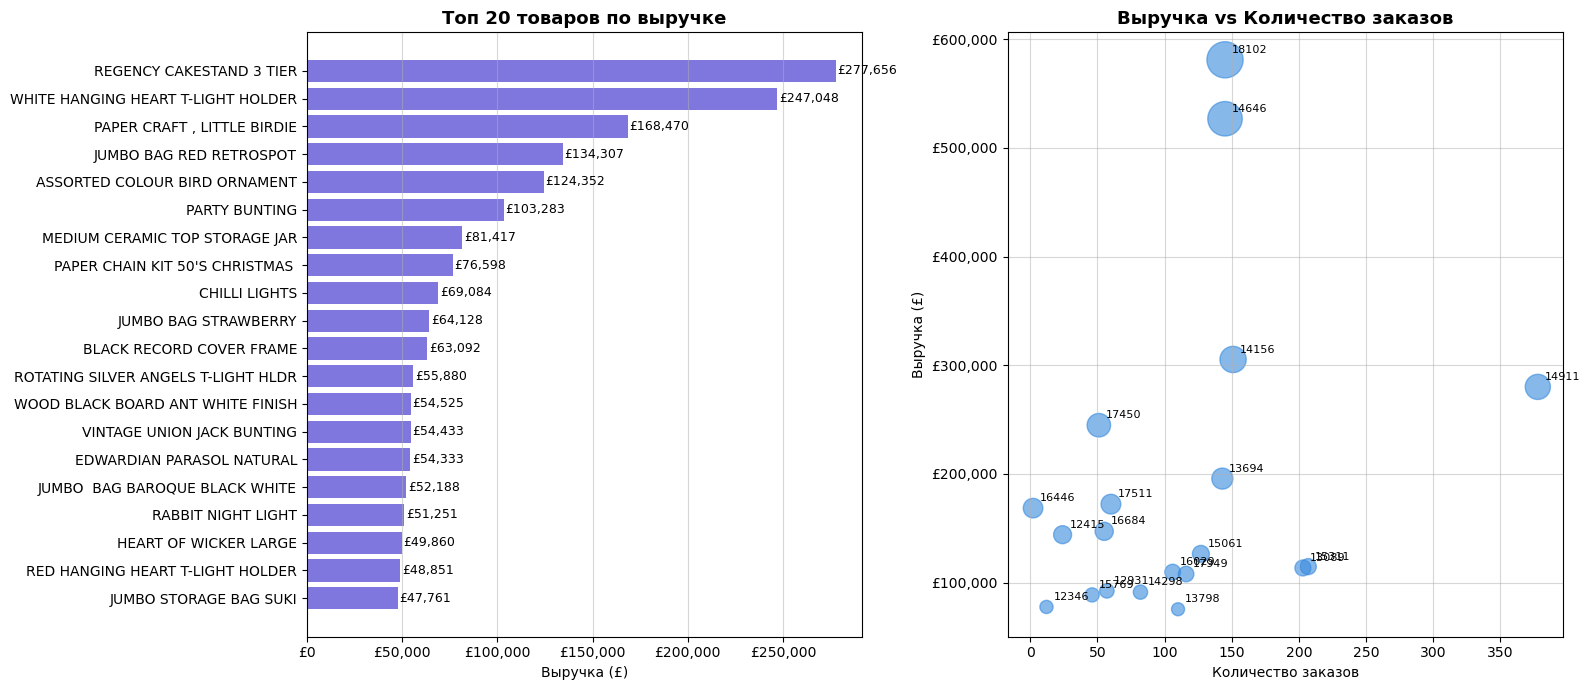

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))
axes[0].barh(
    df_products['Description'],
    df_products['total_revenue'],
    color='#7F77DD'
)
for i, value in enumerate(df_products['total_revenue']):
    axes[0].text(
        value + 1000,
        i,
        f'£{value:,.0f}',
        va='center', fontsize=9
    )
axes[0].set_title('Топ 20 товаров по выручке', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Выручка (£)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.5)

scatter = axes[1].scatter(
    df_customers['orders'],
    df_customers['total_revenue'],
    s = df_customers['revenue_share_pct']*200,
    color='#378ADD',
    alpha=0.6
)

for _, row in df_customers.iterrows():
    axes[1].annotate(
        str(int(row['Customer ID'])),
        (row['orders'], row['total_revenue']),
        fontsize=8,
        xytext=(5,5),
        textcoords = 'offset points'
    )
axes[1].set_title('Выручка vs Количество заказов', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Выручка (£)')
axes[1].set_xlabel('Количество заказов')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.savefig('top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
with engine.connect() as conn:
    df_cumulative = pd.read_sql(text("""
        SELECT 
            DATE_TRUNC('month', "InvoiceDate") as month,
            ROUND(SUM("Revenue")::numeric, 2) as revenue,
            -- Накопительный итог
            ROUND(SUM(SUM("Revenue")) OVER (
                ORDER BY DATE_TRUNC('month', "InvoiceDate")
            )::numeric, 2) as cumulative_revenue,
            -- Скользящее среднее за 3 месяца
            ROUND(AVG(SUM("Revenue")) OVER (
                ORDER BY DATE_TRUNC('month', "InvoiceDate")
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            )::numeric, 2) as moving_avg_3m
        FROM transactions
        GROUP BY DATE_TRUNC('month', "InvoiceDate")
        ORDER BY month
    """), conn)

print(df_cumulative)

        month     revenue  cumulative_revenue  moving_avg_3m
0  2009-12-01   678379.57           678379.57      678379.57
1  2010-01-01   537491.50          1215871.07      607935.54
2  2010-02-01   498137.57          1714008.64      571336.21
3  2010-03-01   666373.67          2380382.31      567334.25
4  2010-04-01   585499.93          2965882.24      583337.06
5  2010-05-01   592934.13          3558816.37      614935.91
6  2010-06-01   629990.45          4188806.82      602808.17
7  2010-07-01   582147.96          4770954.78      601690.85
8  2010-08-01   595111.17          5366065.95      602416.53
9  2010-09-01   805944.81          6172010.76      661067.98
10 2010-10-01  1012421.50          7184432.26      804492.49
11 2010-11-01  1157278.39          8341710.65      991881.57
12 2010-12-01   565749.56          8907460.21      911816.48
13 2011-01-01   562882.91          9470343.12      761970.29
14 2011-02-01   442493.59          9912836.71      523708.69
15 2011-03-01   583843.8

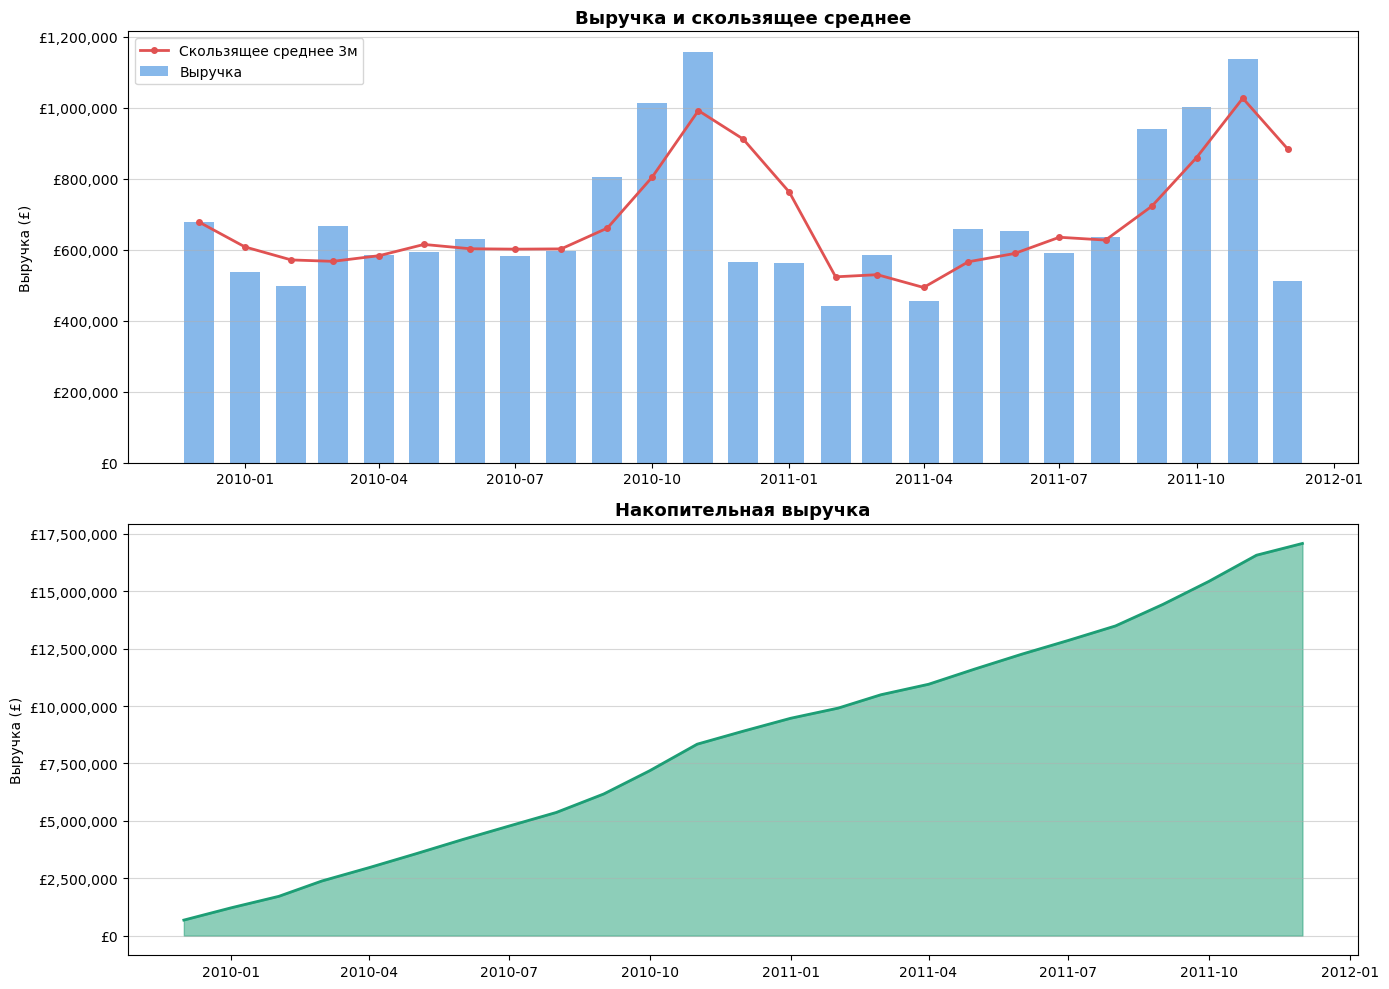

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- График 1: выручка + скользящее среднее ---
axes[0].bar(df_cumulative['month'], df_cumulative['revenue'],
            color='#378ADD', width=20, alpha=0.6, label='Выручка')
axes[0].plot(df_cumulative['month'], df_cumulative['moving_avg_3m'],
             color='#E05252', linewidth=2, marker='o',
             markersize=4, label='Скользящее среднее 3м')
axes[0].set_title('Выручка и скользящее среднее', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Выручка (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].legend()
axes[0].grid(axis='y', alpha=0.5)

# --- График 2: накопительный итог ---
axes[1].fill_between(df_cumulative['month'],
                     df_cumulative['cumulative_revenue'],
                     color='#1D9E75', alpha=0.5, label='Накопительно')
axes[1].plot(df_cumulative['month'], df_cumulative['cumulative_revenue'],
             color='#1D9E75', linewidth=2)
axes[1].set_title('Накопительная выручка', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Выручка (£)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('cumulative_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
with engine.connect() as conn:
    df_lag = pd.read_sql(text("""
        SELECT 
            DATE_TRUNC('month', "InvoiceDate") as month,
            ROUND(SUM("Revenue")::numeric, 2) as revenue,
            -- Выручка предыдущего месяца
            ROUND(LAG(SUM("Revenue")) OVER (
                ORDER BY DATE_TRUNC('month', "InvoiceDate")
            )::numeric, 2) as prev_month_revenue,
            -- Выручка следующего месяца
            ROUND(LEAD(SUM("Revenue")) OVER (
                ORDER BY DATE_TRUNC('month', "InvoiceDate")
            )::numeric, 2) as next_month_revenue,
            -- Прирост к предыдущему месяцу в %
            ROUND((
                (SUM("Revenue") - LAG(SUM("Revenue")) OVER (
                    ORDER BY DATE_TRUNC('month', "InvoiceDate")
                )) / LAG(SUM("Revenue")) OVER (
                    ORDER BY DATE_TRUNC('month', "InvoiceDate")
                ) * 100)
            ::numeric, 2) as mom_growth_pct
        FROM transactions
        GROUP BY DATE_TRUNC('month', "InvoiceDate")
        ORDER BY month
    """), conn)

print(df_lag)

        month     revenue  prev_month_revenue  next_month_revenue  \
0  2009-12-01   678379.57                 NaN           537491.50   
1  2010-01-01   537491.50           678379.57           498137.57   
2  2010-02-01   498137.57           537491.50           666373.67   
3  2010-03-01   666373.67           498137.57           585499.93   
4  2010-04-01   585499.93           666373.67           592934.13   
5  2010-05-01   592934.13           585499.93           629990.45   
6  2010-06-01   629990.45           592934.13           582147.96   
7  2010-07-01   582147.96           629990.45           595111.17   
8  2010-08-01   595111.17           582147.96           805944.81   
9  2010-09-01   805944.81           595111.17          1012421.50   
10 2010-10-01  1012421.50           805944.81          1157278.39   
11 2010-11-01  1157278.39          1012421.50           565749.56   
12 2010-12-01   565749.56          1157278.39           562882.91   
13 2011-01-01   562882.91         

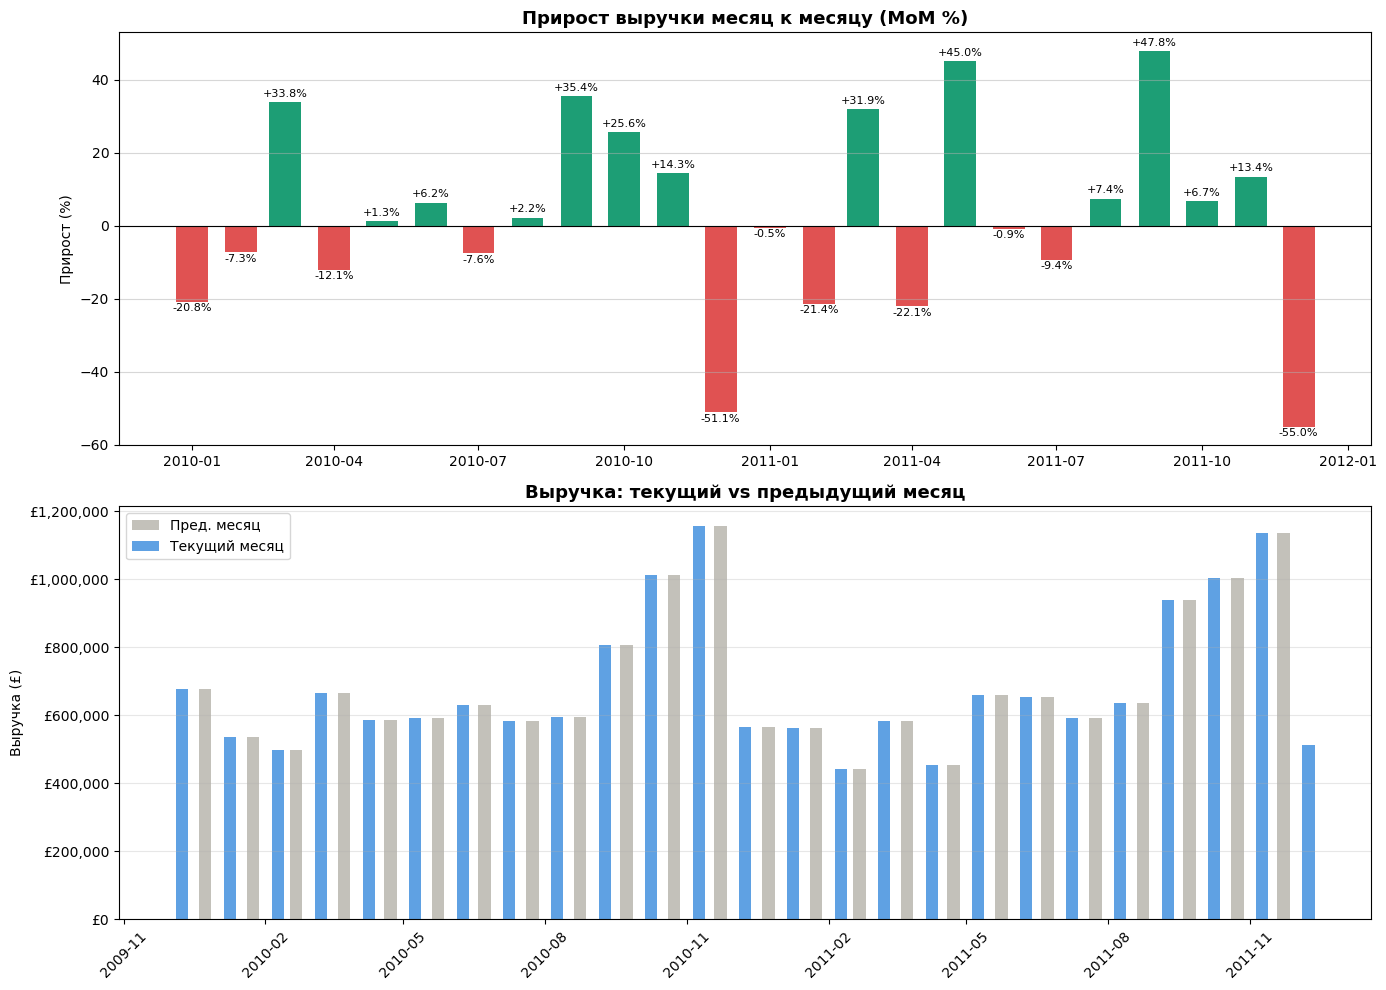

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- График 1: выручка + прирост ---
color_bars = ['#1D9E75' if x >= 0 else '#E05252' 
              for x in df_lag['mom_growth_pct'].fillna(0)]

axes[0].bar(df_lag['month'], df_lag['mom_growth_pct'],
            color=color_bars, width=20)
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].set_title('Прирост выручки месяц к месяцу (MoM %)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Прирост (%)')
axes[0].grid(axis='y', alpha=0.5)

# Подписи на столбцах
for i, (month, val) in enumerate(zip(df_lag['month'],
                                      df_lag['mom_growth_pct'])):
    if pd.notna(val):
        axes[0].text(
            month, val + (1.5 if val >= 0 else -2.5),
            f'{val:+.1f}%',
            ha='center', fontsize=8
        )

# --- График 2: выручка текущий vs предыдущий месяц ---
x = mdates.date2num(df_lag['month'])
bar_width = 8  # теперь просто дни как числа
shift = 8

axes[1].bar(x - shift, df_lag['prev_month_revenue'],
            width=bar_width,
            color='#B4B2A9', alpha=0.8, label='Пред. месяц')
axes[1].bar(x + shift, df_lag['revenue'],
            width=bar_width,
            color='#378ADD', alpha=0.8, label='Текущий месяц')

# Возвращаем читаемые даты на ось X
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

axes[1].set_title('Выручка: текущий vs предыдущий месяц',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Выручка (£)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('mom_growth.png', dpi=150, bbox_inches='tight')
plt.show()